# Step by step through the signal mapping refinement

## Inspecting the refinement

In [79]:
import pod5
from remora import io, refine_signal_map
from pathlib import Path
import numpy as np
test_data_root = Path("../example_data")
pod5_dr = pod5.DatasetReader(test_data_root)
bam_fh = io.ReadIndexedBam(test_data_root / "can_mappings.bam")

read_id = "6e37823a-9398-4be8-b111-65cab029f4e0"
pod5_read = pod5_dr.get_read(read_id)
bam_read = bam_fh.get_first_alignment(read_id)

read = io.Read.from_pod5_and_alignment(pod5_read, bam_read)
query_to_signal_initial = read.query_to_signal
ref_to_signal_initial = read.ref_to_signal

Indexing BAM by parent read id: 14 Reads [00:00, 8246.07 Reads/s]


In [80]:
level_table = test_data_root / "levels.txt"
sig_map_refiner = refine_signal_map.SigMapRefiner(
    kmer_model_filename=level_table,
    do_rough_rescale=True,
    scale_iters=0,
    do_fix_guage=True,
)

read.set_refine_signal_mapping(sig_map_refiner)
read.set_refine_signal_mapping(sig_map_refiner, ref_mapping=True)

query_to_signal_refined = read.query_to_signal
ref_to_signal_refined = read.ref_to_signal


In [81]:
import plotly.graph_objects as go

def plot_comparison(initial: list[int], refined: list[int], title: str, start_idx: int = 0, end_idx: int = 100):
    fig = go.Figure()

    lines_connect = []
    lines = []
    for i, (x_i, x_r) in enumerate(zip(initial[start_idx:end_idx], refined[start_idx:end_idx])):
        line = go.Scatter(x=[x_i, x_r], y=[3,2], line=dict(dash='dot', color="grey"), showlegend=False)
        lines_connect.append(line)

        lines.append(
            go.Scatter(
                x=[x_i,x_i], 
                y=[3,4], 
                mode="lines+markers", 
                line_color="green", 
                name="initial", 
                showlegend=True if i==0 else False
            )
        )

        lines.append(
            go.Scatter(
                x=[x_r,x_r], 
                y=[1,2], 
                mode="lines+markers", 
                line_color="red", 
                name="refined", 
                showlegend=True if i==0 else False
            )
        )

    fig.add_traces(lines_connect)
    fig.add_traces(lines)

    fig.update_layout(title_text=title)
    
    fig.layout.yaxis.fixedrange = True
    return fig

In [82]:
plot_comparison(query_to_signal_initial, query_to_signal_refined, "Query to signal").show()
plot_comparison(ref_to_signal_initial, ref_to_signal_refined, "Ref to signal").show()

## Looking into the code

## Process the k-mer table

### 1. When initializing the SigMapRefiner in refine_signal_map.py

In [83]:
path = level_table
do_fix_gauge = True

Reads a file containing k-mers (short DNA sequences) and their corresponding signal levels

In [84]:
str_kmer_levels = {}
with open(path) as kmer_fp:
    kmer_len = len(kmer_fp.readline().split()[0])
    kmer_fp.seek(0)
    for line in kmer_fp:
        kmer, level = line.split()
        kmer = kmer.upper()
        if kmer in str_kmer_levels:
            raise Exception(
                f"K-mer found twice in levels file '{kmer}'."
            )
        if kmer_len != len(kmer):
            raise Exception(
                f"K-mer lengths not all equal '{len(kmer)} != "
                f"{kmer_len}' for {kmer}."
            )
        try:
            str_kmer_levels[kmer] = float(level)
            if np.isnan(str_kmer_levels[kmer]):
                str_kmer_levels[kmer] = 0
        except ValueError:
            raise Exception(
                f"Could not convert level to float '{level}'"
            )
if len(str_kmer_levels) != 4**kmer_len:
    raise Exception(
        "K-mer table contains fewer entries "
        f"({len(str_kmer_levels)}) than expected "
        f"({4 ** kmer_len})"
    )

str_kmer_levels

{'AAAAAAAAA': -1.8424464464187622,
 'AAAAAAAAC': -1.6519798040390015,
 'AAAAAAAAG': -1.7665722370147705,
 'AAAAAAAAT': -1.6588099002838135,
 'AAAAAAACA': -1.4318406581878662,
 'AAAAAAACC': -1.3386551141738892,
 'AAAAAAACG': -1.4139249324798584,
 'AAAAAAACT': -1.2813042402267456,
 'AAAAAAAGA': -1.547182321548462,
 'AAAAAAAGC': -1.372792363166809,
 'AAAAAAAGG': -1.5156818628311157,
 'AAAAAAAGT': -1.3663585186004639,
 'AAAAAAATA': -1.5391128063201904,
 'AAAAAAATC': -1.4767426252365112,
 'AAAAAAATG': -1.4849002361297607,
 'AAAAAAATT': -1.5046041011810303,
 'AAAAAACAA': -0.01155514270067215,
 'AAAAAACAC': 0.4183123707771301,
 'AAAAAACAG': 0.027864579111337662,
 'AAAAAACAT': 0.4778972268104553,
 'AAAAAACCA': 0.17478756606578827,
 'AAAAAACCC': 0.5262953639030457,
 'AAAAAACCG': 0.2744098901748657,
 'AAAAAACCT': 0.4068562686443329,
 'AAAAAACGA': 0.08549079298973083,
 'AAAAAACGC': 0.5150769352912903,
 'AAAAAACGG': 0.07819439470767975,
 'AAAAAACGT': 0.5124853253364563,
 'AAAAAACTA': 0.15153394639

- Tries to find which position in the k-mer has the strongest influence on the signal level
- For each position, groups k-mers by the base (A, C, G, or T) at that position
- Uses a statistical test (Kruskal-Wallis) to see which position shows the strongest pattern
- Stores the most influential position as center_idx

In [85]:
from scipy import stats

sorted_kmers = sorted(
    (level, kmer) for kmer, level in str_kmer_levels.items()
)
kmer_idx_stats = []

# For each position in the k-mer
for kmer_idx in range(kmer_len):
    kmer_idx_pos = []
    # for each base
    for base in "ACGT":
        # collect the indices of the kmers that have the current base at the current index 
        kmer_idx_pos.append(
            [
                levels_idx
                for levels_idx, (_, kmer) in enumerate(sorted_kmers)
                if kmer[kmer_idx] == base
            ]
        )
    # compute Kruskal-Wallis H-test statistics for non-random ordering
    # of groups, indicating the dominant position within the k-mer
    kmer_idx_stats.append(stats.kruskal(*kmer_idx_pos)[0])
center_idx = int(np.argmax(kmer_idx_stats))
center_idx

6

- This is a normalization method to make the signal levels more comparable
- Calculates the median and median absolute deviation (MAD) of all levels
- Normalizes the data by subtracting the median and dividing by MAD
- Stores the normalized values back in the k-mer table

In [86]:
from itertools import product

def index_from_kmer(kmer, alphabet="ACGT"):
    """Encode string k-mer as integer via len(alphabet)-bit encoding.

    A utility function that converts a k-mer string into a unique number
    Uses the position of each base in the alphabet to create a unique encoding
    For example, "AAA" in the alphabet "ACG" would be encoded as 0
    
    Args:
        kmer (str): kmer string
        alphabet (str): bases used. Default: ACGT

    Returns:
        int: bit encoded kmer

    Example:
        index_from_kmer('AAA', 'ACG')               returns 0
        index_from_kmer('CAAAAAAAA', 'ACGTVWXYX')   returns 65536
    """
    return sum(
        alphabet.find(base) * (len(alphabet) ** kmer_pos)
        for kmer_pos, base in enumerate(kmer[::-1])
    )


str_kmer_levels_before = str_kmer_levels

if do_fix_gauge:
    levels_array = np.empty(4**kmer_len, dtype=np.float32)
    for kmer, level in str_kmer_levels.items():
        levels_array[index_from_kmer(kmer)] = level

    med = np.median(levels_array)
    # note factor to scale MAD to SD
    mad = np.median(np.absolute(levels_array - med)) * 1.4826
    levels_array = (levels_array - med) / mad
    str_kmer_levels = {}
    for kmer in product(*["ACGT"] * kmer_len):
        str_kmer_levels["".join(kmer)] = levels_array[
            index_from_kmer(kmer)
        ]

for k in list(str_kmer_levels_before.keys())[1000:1050]:
    print(str_kmer_levels_before[k], str_kmer_levels[k])

0.24552080035209656 0.086347185
0.13953806459903717 0.0098006595
0.34209370613098145 0.15609741
0.09291820228099823 -0.023870753
0.009800429455935955 -0.083902955
0.09868115931749344 -0.01970843
0.10059048235416412 -0.018329414
0.1801409125328064 0.039126255
0.40250661969184875 0.19973092
0.37462836503982544 0.17959572
0.4061684012413025 0.20237568
0.47698092460632324 0.25352034
0.4467330574989319 0.23167369
0.4450318217277527 0.23044497
0.46042683720588684 0.24156407
0.4327574074268341 0.22157969
0.5017200112342834 0.27138826
0.5782868266105652 0.326689
0.4955814778804779 0.26695466
0.6716303825378418 0.39410684
0.2729215919971466 0.10613754
0.2738039791584015 0.106774844
0.30085209012031555 0.12631047
0.26762741804122925 0.102313794
-1.9427882432937622 -1.4941692
-1.779774785041809 -1.3764321
-1.887079119682312 -1.4539331
-1.7549574375152588 -1.3585076
-1.581391453742981 -1.2331487
-1.5247752666473389 -1.1922574
-1.5748205184936523 -1.2284029
-1.4423456192016602 -1.1327223
-1.6671068

## Starting the refinement

### 2. When calling set_refine_signal_mapping on a Read in io.py

In [87]:
ref_mapping = False

#### 2.1 in into_remora_read

In [88]:
if ref_mapping:
    trim_dacs = read.dacs[read.ref_to_signal[0] : read.ref_to_signal[-1]]
    shift_seq_to_sig = read.ref_to_signal - read.ref_to_signal[0]
    seq = read.ref_seq
else:
    trim_dacs = read.dacs[read.query_to_signal[0] : read.query_to_signal[-1]]
    shift_seq_to_sig = read.query_to_signal - read.query_to_signal[0]
    seq = read.seq

##### 2.1.1 in RemoraRead init (data_chunks.py)

In [89]:
np.mean(read.dacs)

863.1600427709831

In [90]:
read.shift_dacs_to_pa

289.0

In [91]:
read.scale_dacs_to_pa

6.839614789961872

In [92]:
dacs = trim_dacs
seq_to_sig_map = shift_seq_to_sig
str_seq = seq
read_id = read.read_id
read_metrics = read.read_metrics
shift = read.shift_dacs_to_norm
scale = read.scale_dacs_to_norm

##### 2.1.1.1 in seq_to_int (util.py)

In [93]:
SEQ_MIN = np.array(["A"], dtype="S1").view(np.uint8)[0]
SEQ_TO_INT_ARR = np.full(26, -1, dtype=int)
SEQ_TO_INT_ARR[0] = 0
SEQ_TO_INT_ARR[2] = 1
SEQ_TO_INT_ARR[6] = 2
SEQ_TO_INT_ARR[19] = 3
SEQ_TO_INT_ARR

int_seq = SEQ_TO_INT_ARR[np.array(list(seq), dtype="c").view(np.uint8) - SEQ_MIN]

#### 2.2 in RemoraRead.refine_signal_mapping (data_chunks.py; called in set_refine_signal_mapping)

In [94]:
do_rough_recale = False
scale_iters = 0

## Rough rescaling

##### 2.2.1 in SigMapRefiner.rough_rescale

In [95]:
shift
scale
seq_to_sig_map
int_seq
dacs

array([ 987,  990, 1011, ...,  779,  745,  733], dtype=int16)

In [96]:
quants=np.arange(0.05, 1, 0.05)
clip_bases=10
use_base_center=True
rough_rescale_method = "least_squares"

###### 2.2.1.1 in SigMapRefiner.extract_levels

Extract the levels as given in the level table 

In [97]:
def index_from_int_kmer(int_kmer, kmer_len):
    idx = 0
    for kmer_pos in range(kmer_len):
        idx += int_kmer[kmer_len - kmer_pos - 1] * (4 ** kmer_pos)
    return idx

In [98]:
levels = np.zeros(len(int_seq), dtype=np.float32)
for pos in range(len(int_seq) - kmer_len + 1):
    center_pos = pos + center_idx
    kmer = int_seq[pos:pos + kmer_len]
    kmer_idx = index_from_int_kmer(kmer, kmer_len)
    levels[center_pos] = levels_array[kmer_idx]

##### 2.2.1 back in SigMapRefiner.rough_rescale

In [99]:
seq_to_sig_map

array([    0,     4,     8, ..., 83226, 83230, 83234], dtype=int32)

Those are the middle points between each interval in the seq_to_sig mapping:

In [100]:
(seq_to_sig_map[:-1] + seq_to_sig_map[1:]) // 2

array([    2,     6,    10, ..., 83214, 83228, 83232], dtype=int32)

When using only the center measurements for each base: (much fewer values -> more efficient)

In [101]:
dacs[(seq_to_sig_map[:-1] + seq_to_sig_map[1:]) // 2].size

6902

When using all measurements for a given base:

In [102]:
dacs[seq_to_sig_map[0] : seq_to_sig_map[-1]].size

83234

In [103]:
if use_base_center:
    # Takes the middle point of each base's signal
    optim_dacs = dacs[(seq_to_sig_map[:-1] + seq_to_sig_map[1:]) // 2]
    if clip_bases > 0 and levels.size > clip_bases*2:
        # Removes specified number of bases from start/end
        levels = levels[clip_bases:-clip_bases]
        optim_dacs = optim_dacs[clip_bases:-clip_bases]
else:
    # Uses all signal points between first and last base
    optim_dacs = dacs[seq_to_sig_map[0] : seq_to_sig_map[-1]]

In [104]:
def rough_rescale_lstsq(dacs, levels, shift, scale, quants):
    norm_sig = (dacs - shift) / scale
    norm_qs = np.quantile(norm_sig, quants)
    shift_est, scale_est = np.linalg.lstsq(
        np.column_stack([np.ones_like(norm_qs), norm_qs]),
        np.quantile(levels, quants),
        rcond=None,
    )[0]
    if scale_est == 0:
        return shift, scale
    new_shift = shift - (scale * shift_est / scale_est)
    new_scale = scale / scale_est
    return new_shift, new_scale


###### 2.2.1.2 in rescale_lstqu

Normalize the signal with the initial factors:

In [105]:
norm_sig = (dacs - shift) / scale
print(dacs, dacs.size)
print(norm_sig, norm_sig.size)

[ 987  990 1011 ...  779  745  733] 83234
[ 0.59774305  0.61292698  0.7192145  ... -0.45500953 -0.62709408
 -0.68782981] 83234


Calculate the following quantiles from the signal and reshape them into a matrix:

In [106]:
print("Quantiles used here:\n", quants, quants.shape, "\n")

norm_qs = np.quantile(norm_sig, quants)
print("These quantile values from the signal:\n", norm_qs, norm_qs.shape, "\n")

norm_qs_as_matrix = np.column_stack([np.ones_like(norm_qs), norm_qs])
print("Transformed into a matrix shape:\n", norm_qs_as_matrix, norm_qs_as_matrix.shape, "\n")

Quantiles used here:
 [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95] (19,) 

These quantile values from the signal:
 [-1.15347037e+00 -1.03706023e+00 -9.45956645e-01 -8.54853056e-01
 -7.58688157e-01 -6.27094084e-01 -4.14519044e-01 -1.86760072e-01
  5.08415945e-04  1.27041178e-01  2.28267388e-01  3.14309666e-01
  3.95290634e-01  4.76271601e-01  5.52191259e-01  6.38233537e-01
  7.39459747e-01  8.71053819e-01  1.03807707e+00] (19,) 

Transformed into a matrix shape:
 [[ 1.00000000e+00 -1.15347037e+00]
 [ 1.00000000e+00 -1.03706023e+00]
 [ 1.00000000e+00 -9.45956645e-01]
 [ 1.00000000e+00 -8.54853056e-01]
 [ 1.00000000e+00 -7.58688157e-01]
 [ 1.00000000e+00 -6.27094084e-01]
 [ 1.00000000e+00 -4.14519044e-01]
 [ 1.00000000e+00 -1.86760072e-01]
 [ 1.00000000e+00  5.08415945e-04]
 [ 1.00000000e+00  1.27041178e-01]
 [ 1.00000000e+00  2.28267388e-01]
 [ 1.00000000e+00  3.14309666e-01]
 [ 1.00000000e+00  3.95290634e-01]
 [ 1.00000000e+00  4.76271

The same quantiles from the expected levels of each kmer:
 [-1.16497333 -1.04904064 -0.97191405 -0.89635208 -0.82437392 -0.74323633
 -0.55932321 -0.26937823 -0.08190138  0.02588534  0.11952017  0.20712859
  0.29624577  0.39356101  0.50397544  0.61607397  0.72705083  0.85605032
  1.01398882] (19,) 



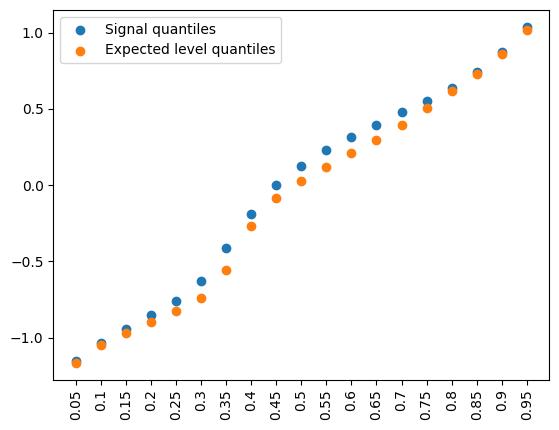

In [107]:
levels_qs = np.quantile(levels, quants)
print("The same quantiles from the expected levels of each kmer:\n", levels_qs, levels_qs.shape, "\n")

import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.scatter(x=range(19), y=norm_qs, label="Signal quantiles")
ax.scatter(x=range(19), y=levels_qs, label="Expected level quantiles")
ax.legend()
ax.set_xticks(range(19), quants.round(2), rotation=90);

The goal is to transform the signal (blue line) in a way that better aligns with the expected signal (orange line).

In [108]:
shift_est, scale_est = np.linalg.lstsq(norm_qs_as_matrix, levels_qs, rcond=None)[0]
print(shift_est, scale_est)


-0.06330382382867158 1.0009083373225052


Old shift and scale:	 868.8995485562593 | 197.57728815147718
New shift and scale:	 881.3955957718774 | 197.39798419504552


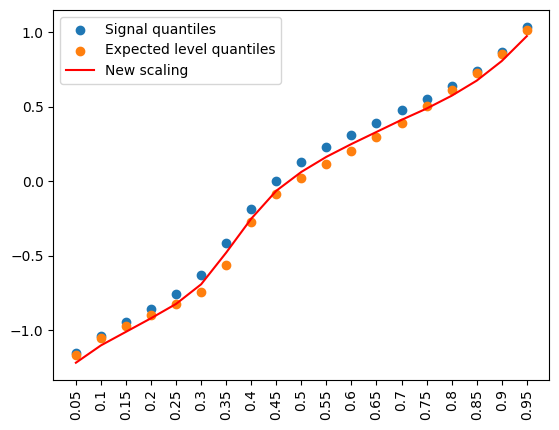

In [109]:
if scale_est == 0:
    new_shift, new_scale = shift, scale
else:
    new_shift = shift - (scale * shift_est / scale_est)
    new_scale = scale / scale_est

print(f"Old shift and scale:\t {shift} | {scale}")
print(f"New shift and scale:\t {new_shift} | {new_scale}")

fig, ax = plt.subplots()

ax.scatter(x=range(19), y=norm_qs, label="Signal quantiles")
ax.scatter(x=range(19), y=levels_qs, label="Expected level quantiles")
ax.plot(np.quantile((read.dacs - new_shift) / scale, quants), label="New scaling", c="red")
ax.legend()
ax.set_xticks(range(19), quants.round(2), rotation=90);

The alternative is to use the Theil-Sen approach:

The key differences between Theil-Sen and least squares are:
- Slope Calculation:
  - Least squares: Minimizes sum of squared vertical distances from points to line
  - Theil-Sen: Takes median of all possible pairwise slopes

- Intercept Calculation:
  - Least squares: Comes from solving normal equations
  - Theil-Sen: Takes median of all possible intercepts using y = mx + b
 
- Robustness:
  - Theil-Sen is more robust to outliers because it uses medians
  - Can handle up to 29.3% of the data being outliers
  

However, it's more computationally intensive since it needs to compute O(n²) slopes for n points! (which is why the code has the MAX_POINTS_FOR_THEIL_SEN limit, after that random subsetting is performed)

##### 2.2.2 in SigMapRefiner.refine_sig_map

In [110]:
scale_iters = 1

In [111]:
shift = new_shift
print(shift)
scale = new_scale
print(scale)
seq_to_sig_map
print(seq_to_sig_map, seq_to_sig_map.shape)
int_seq
print(int_seq, int_seq.shape)
dacs
print(dacs, dacs.shape)

881.3955957718774
197.39798419504552
[    0     4     8 ... 83226 83230 83234] (6903,)
[2 3 2 ... 1 0 3] (6902,)
[ 987  990 1011 ...  779  745  733] (83234,)


###### 2.2.2.1 in SigMapRefiner.extract_levels

In [112]:
def index_from_int_kmer(int_kmer, kmer_len):
    idx = 0
    for kmer_pos in range(kmer_len):
        idx += int_kmer[kmer_len - kmer_pos - 1] * (4 ** kmer_pos)
    return idx

levels = np.zeros(len(int_seq), dtype=np.float32)
for pos in range(len(int_seq) - kmer_len + 1):
    center_pos = pos + center_idx
    kmer = int_seq[pos:pos + kmer_len]
    kmer_idx = index_from_int_kmer(kmer, kmer_len)
    levels[center_pos] = levels_array[kmer_idx]

##### back in SigMapRefiner.refine_sig_map

In [113]:
dacs = dacs[seq_to_sig_map[0]:seq_to_sig_map[-1]]
sig_st = seq_to_sig_map[0]
seq_to_sig_map = seq_to_sig_map - sig_st

The following code until 'ENDFOR' is in for loop with the specified number of iterations.

###### 2.2.2.1 in SigMapRefiner.refine_signal_mapping

In [114]:
def compute_dwell_pen_array(target, limit, weight):
    if limit > target:
        # LOGGER.warning(
        #     f"Requested short dwell limit ({limit}) is greater than target "
        #     f"dwell ({target}). Setting limit to target."
        # )
        limit = target
    return weight * np.square(np.arange(limit, dtype=np.float32) - target)

In [115]:
signal = (dacs - shift) / scale
seq_to_sig_map
levels
band_half_width = 5 # default
refine_algo = "dwell_penalty" # default
short_dwell_pen = compute_dwell_pen_array(4,3,0.5) # default
adjust_band_min_step = 2

Trim the signal to include only the relevant portion and adjust the mapping coordinates accordingly (as seen before)

In [116]:
signal = signal[seq_to_sig_map[0] : seq_to_sig_map[-1]]
sig_map_start = 0
if seq_to_sig_map[0] != 0:
    sig_map_start = seq_to_sig_map[0]
    seq_to_sig_map = np.copy(seq_to_sig_map)
    seq_to_sig_map -= seq_to_sig_map[0]

## Computing Signal bands

###### in compute_sig_band

In [117]:
bps = seq_to_sig_map
levels
bhw = band_half_width
is_banded = True

Calculate the distance between the i+1th and the ith point (`d(i) = v(i+1) - v(i)`)

In [118]:
d = np.diff(bps)
print(d, d.shape)

[ 4  4  4 ... 23  4  4] (6902,)


In [119]:
seq_len = levels.size
sig_len = bps[-1] - bps[0] # signal length 
print(seq_len, sig_len)

6902 83234


This gives an array where an index i from the sequence is repeated as often as the number of measurements assigned to the base. This basically maps sequence indices to signal indices.

For example: the base at index i=20 has 7 signal measurements assigned to it, then it looks as follows:

```
[..., 20, 20, 20, 20, 20, 20, 20, ...]
```

In [120]:
seq_indices = np.repeat(np.arange(seq_len), d)
print(seq_indices[:10], seq_indices.shape)

[0 0 0 0 1 1 1 1 2 2] (83234,)


Initialize the bands:

In [121]:
band = np.empty((2, sig_len), dtype=np.int32)
print(band, band.shape)

[[1300251376      30999 1054479520 ...          0       3439          0]
 [      3439          0       3439 ...          0       6901          0]] (2, 83234)


For an given positition on the sequence i, the band object contains a start index at `[0,i]` and an end index at `[1,i]`. 

If is_banded is True, the given start and end index is located in a distance of bhw around the sequence index of the current signal measurement. Otherwise the entire sequence is regarded.

In [122]:
if is_banded:
    # Use specific band if instructed
    band[0, :] = np.maximum(seq_indices - bhw, 0)
    band[1, :] = np.minimum(seq_indices + bhw + 1, seq_len)
else:
    # otherwise specify entire input matrix
    band[0, :] = 0
    band[1, :] = seq_len

print(band[:, :50], band.shape)

[[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1
   1  1]
 [ 6  6  6  6  7  7  7  7  8  8  8  8  9  9  9  9 10 10 10 10 10 10 10 10
  10 10 10 10 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 12 12
  12 12]] (2, 83234)


Find the positions in the SIGNAL where the corresponding level on the SEQUENCE is NaN:

In [123]:
# Modify bands based on invalid levels
nan_mask = np.in1d(seq_indices, np.nonzero(np.isnan(levels)))
print(nan_mask, nan_mask.shape)

[False False False ... False False False] (83234,)


Get the indices of the signal positions corresponding to NaN levels:

In [124]:
nan_sig_indices = np.where(nan_mask)[0]
print(nan_sig_indices, nan_sig_indices.shape)

[] (0,)


Also extract these indices from the seq_indices:

In [125]:
nan_seq_indices = seq_indices[nan_mask]
print(nan_seq_indices, nan_seq_indices.shape)

[] (0,)


Update the bands at these NaN positions to restrict the band to only the current base (no flexibility). This prevents the algorithm from using invalid levels in its optimization.

In [126]:
band[0, nan_sig_indices] = nan_seq_indices
band[1, nan_sig_indices] = nan_seq_indices + 1

print(band[:, :50], band.shape)

[[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1
   1  1]
 [ 6  6  6  6  7  7  7  7  8  8  8  8  9  9  9  9 10 10 10 10 10 10 10 10
  10 10 10 10 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 11 12 12
  12 12]] (2, 83234)


After replacing the values with the indices themselves, it can happen that the bands do not increase monotonically. To fix this around band near NaN levels, use the accumulate function:

In [127]:
np.maximum.accumulate([10,11,12,9,8,10,13,14,7,15])

array([10, 11, 12, 12, 12, 12, 13, 14, 14, 15])

In [128]:
# Modify bands close to invalid levels so monotonically increasing
band[0, :] = np.maximum.accumulate(band[0, :])
band[1, :] = np.minimum.accumulate(band[1, ::-1])[::-1]

Example of bands:

```
Signal Position:    0 1 2 3 4 5 6 7 8 9
Lower Bound:        0 0 0 1 1 2 2 3 3 4
Upper Bound:        2 2 3 3 4 4 5 5 6 6
```

- At signal position 0, we can look at bases 0-1
- At signal position 5, we can look at bases 2-3
- And so on...

The band defines where the algorithm can search for better mappings while maintaining the order of bases and handling any invalid or missing data appropriately.

##### back to refine_signal_mapping

## Computing Sequence bands

In [129]:
sig_band = band

###### in convert_to_seq_band

In [130]:
sig_band

array([[   0,    0,    0, ..., 6896, 6896, 6896],
       [   6,    6,    6, ..., 6902, 6902, 6902]], dtype=int32)

In [131]:
sig_len = sig_band.shape[1]  # Length of signal
seq_len = sig_band[1, -1]    # Length of sequence (from last upper boundary)

Initialize the seq_band array and initialize it with 0 for the lower bounds and the signal length for the upper bounds:

In [132]:
seq_band = np.zeros((2, seq_len), dtype=np.int32)
seq_band[1, :] = sig_len     # Initialize upper bounds to max signal length
print(seq_band, seq_band.shape)

[[    0     0     0 ...     0     0     0]
 [83234 83234 83234 ... 83234 83234 83234]] (2, 6902)


Calculate the lower limits. This is done by finding positions where the value changes using the np.ediff1d function (for pos i, calculates i-(i-1) -> if the values are the same this is 0) and extracting the corresponding indices with the np.nonzero function:

In [133]:
print(np.ediff1d([0,1,1,1,1,5], to_begin=0)) # add 0 to beginning of array
print(np.nonzero(np.ediff1d([0,1,1,1,1,5], to_begin=0))[0])

[0 1 0 0 0 4]
[1 5]


In [134]:
# upper signal coordinates define lower sequence boundaries
lower_sig_pos = np.nonzero(np.ediff1d(sig_band[1, :], to_begin=0))[0]
print(lower_sig_pos, lower_sig_pos.shape)

[    4     8    12 ... 83152 83162 83172] (6896,)


In [135]:
lower_base_pos = sig_band[1, lower_sig_pos - 1]
print(lower_base_pos, lower_base_pos.shape)

[   6    7    8 ... 6899 6900 6901] (6896,)


In [136]:
print(seq_band[:, :50])
seq_band[0, lower_base_pos] = lower_sig_pos
print(seq_band[:, :50])

[[    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [83234 83234 83234 83234 83234 83234 83234 83234 83234 83234 83234 83234
  83234 83234 83234 83234 83234 83234 83234 83234 83234 83234 83234 83234
  83234 83234 83234 83234 83234 83234 83234 83234 83234 83234 83234 83234
  83234 83234 83234 83234 83234 83234 83234 83234 83234 83234 83234 83234
  83234 83234]]
[[    0     0     0     0     0     0     4     8    12    16    28    46
     50    70   178   225   271   275   279   283   287   295   299   331
    335   342   362   366   370   384   390   397   407   425   433   459
    463   474   486   490   494   498   507   515   519   526   537   542
    546   557]
 [83234 83234 83234 83234 83234 83234 83234 83234 83234 83234 8323

In [137]:
seq_band[0, :] = np.maximum.accumulate(seq_band[0, :])
print(seq_band[:, :50])


[[    0     0     0     0     0     0     4     8    12    16    28    46
     50    70   178   225   271   275   279   283   287   295   299   331
    335   342   362   366   370   384   390   397   407   425   433   459
    463   474   486   490   494   498   507   515   519   526   537   542
    546   557]
 [83234 83234 83234 83234 83234 83234 83234 83234 83234 83234 83234 83234
  83234 83234 83234 83234 83234 83234 83234 83234 83234 83234 83234 83234
  83234 83234 83234 83234 83234 83234 83234 83234 83234 83234 83234 83234
  83234 83234 83234 83234 83234 83234 83234 83234 83234 83234 83234 83234
  83234 83234]]


Calculate the upper limits. Basically the same process, but using the lower signal band limits:

In [138]:
upper_sig_pos = np.nonzero(np.ediff1d(sig_band[0, :], to_begin=0))[0]
upper_base_pos = sig_band[0, upper_sig_pos]
seq_band[1, upper_base_pos - 1] = upper_sig_pos
seq_band[1, :] = np.minimum.accumulate(seq_band[1, ::-1])[::-1]

In [139]:
print(seq_band[:,:50], seq_band.shape)

[[  0   0   0   0   0   0   4   8  12  16  28  46  50  70 178 225 271 275
  279 283 287 295 299 331 335 342 362 366 370 384 390 397 407 425 433 459
  463 474 486 490 494 498 507 515 519 526 537 542 546 557]
 [ 46  50  70 178 225 271 275 279 283 287 295 299 331 335 342 362 366 370
  384 390 397 407 425 433 459 463 474 486 490 494 498 507 515 519 526 537
  542 546 557 567 578 583 597 604 640 648 665 670 674 681]] (2, 6902)


##### back to refine_signal_mapping

## Adjust the seq_bands

###### in adjust_seq_band (refine_signal_map_core.pyx)

This function ensures the sequence bands meet minimum spacing and ordering requirements before they're used in the dynamic programming algorithm. It's essentially a preprocessing step that enforces constraints like "each base must take up at least X signal positions" and "bases must be processed in sequential order" to make sure the dynamic programming will only consider valid paths.

In [140]:
seq_band_adjusted = seq_band
min_step = 2

band_min = seq_band_adjusted[0, 0]

Iterate backwards through the sequence and ensure that each position in the start positions starts at least min_steps before the next one:

In [141]:
print(seq_band_adjusted[:, :50], seq_band_adjusted.shape)

[[  0   0   0   0   0   0   4   8  12  16  28  46  50  70 178 225 271 275
  279 283 287 295 299 331 335 342 362 366 370 384 390 397 407 425 433 459
  463 474 486 490 494 498 507 515 519 526 537 542 546 557]
 [ 46  50  70 178 225 271 275 279 283 287 295 299 331 335 342 362 366 370
  384 390 397 407 425 433 459 463 474 486 490 494 498 507 515 519 526 537
  542 546 557 567 578 583 597 604 640 648 665 670 674 681]] (2, 6902)


In [142]:
# fix starts to make sure each start is at least min_step less than prev
for seq_pos in range(seq_band_adjusted.shape[1] - 2, -1, -1):
    if seq_band_adjusted[0, seq_pos] > seq_band_adjusted[0, seq_pos + 1] - min_step:
        seq_band_adjusted[0, seq_pos] = seq_band_adjusted[0, seq_pos + 1] - min_step

In [143]:
print(seq_band_adjusted[:, :50], seq_band_adjusted.shape)

[[-10  -8  -6  -4  -2   0   4   8  12  16  28  46  50  70 178 225 271 275
  279 283 287 295 299 331 335 342 362 366 370 384 390 397 407 425 433 459
  463 474 486 490 494 498 507 515 519 526 537 542 546 557]
 [ 46  50  70 178 225 271 275 279 283 287 295 299 331 335 342 362 366 370
  384 390 397 407 425 433 459 463 474 486 490 494 498 507 515 519 526 537
  542 546 557 567 578 583 597 604 640 648 665 670 674 681]] (2, 6902)


Iterate forwards through the lower bounds to ensure that each position is strictly greater than the previous one. This also gets rid of negative values as the minimum value is given to the first position:

(after this the minimum step size is no longer 2 for the first values. But I guess the important thing here is that a value is strictly greater than the previous)

In [144]:
seq_band_adjusted[0, 0] = band_min
seq_pos = 1
while seq_band_adjusted[0, seq_pos] <= seq_band_adjusted[0, seq_pos - 1]:
    seq_band_adjusted[0, seq_pos] = seq_band_adjusted[0, seq_pos - 1] + 1
    seq_pos += 1

In [145]:
print(seq_band_adjusted[:, :50], seq_band_adjusted.shape)


[[  0   1   2   3   4   5   6   8  12  16  28  46  50  70 178 225 271 275
  279 283 287 295 299 331 335 342 362 366 370 384 390 397 407 425 433 459
  463 474 486 490 494 498 507 515 519 526 537 542 546 557]
 [ 46  50  70 178 225 271 275 279 283 287 295 299 331 335 342 362 366 370
  384 390 397 407 425 433 459 463 474 486 490 494 498 507 515 519 526 537
  542 546 557 567 578 583 597 604 640 648 665 670 674 681]] (2, 6902)


Iterating forwards through the end values of the sequence. Like before, ensure that each positions ends at least min_step positions after the previous:

In [146]:
print(seq_band_adjusted[:, -50:], seq_band_adjusted.shape)


[[82522 82533 82549 82581 82587 82592 82609 82616 82635 82646 82684 82728
  82735 82742 82755 82766 82771 82785 82810 82825 82829 82847 82851 82862
  82871 82888 82895 82902 82908 82914 82939 82945 82949 82953 82977 82989
  83007 83025 83030 83036 83042 83046 83063 83078 83097 83144 83148 83152
  83162 83172]
 [82728 82735 82742 82755 82766 82771 82785 82810 82825 82829 82847 82851
  82862 82871 82888 82895 82902 82908 82914 82939 82945 82949 82953 82977
  82989 83007 83025 83030 83036 83042 83046 83063 83078 83097 83144 83148
  83152 83162 83172 83185 83193 83203 83226 83230 83234 83234 83234 83234
  83234 83234]] (2, 6902)


In [147]:
band_max = seq_band_adjusted[1, seq_band.shape[1]-1]
# fix ends to make sure each end is at least min_step more than prev
for seq_pos in range(1, seq_band.shape[1]):
    if seq_band[1, seq_pos] < seq_band[1, seq_pos - 1] + min_step:
        seq_band[1, seq_pos] = seq_band[1, seq_pos - 1] + min_step

In [148]:
print(seq_band_adjusted[:, -50:], seq_band_adjusted.shape)

[[82522 82533 82549 82581 82587 82592 82609 82616 82635 82646 82684 82728
  82735 82742 82755 82766 82771 82785 82810 82825 82829 82847 82851 82862
  82871 82888 82895 82902 82908 82914 82939 82945 82949 82953 82977 82989
  83007 83025 83030 83036 83042 83046 83063 83078 83097 83144 83148 83152
  83162 83172]
 [82728 82735 82742 82755 82766 82771 82785 82810 82825 82829 82847 82851
  82862 82871 82888 82895 82902 82908 82914 82939 82945 82949 82953 82977
  82989 83007 83025 83030 83036 83042 83046 83063 83078 83097 83144 83148
  83152 83162 83172 83185 83193 83203 83226 83230 83234 83236 83238 83240
  83242 83244]] (2, 6902)


And like before, fix the end values to ensure that the upper limit is not exceeded:

In [149]:
seq_band[1, seq_band.shape[1] - 1] = band_max
seq_pos = seq_band.shape[1] - 2
while seq_band[1, seq_pos] >= seq_band[1, seq_pos + 1]:
    seq_band[1, seq_pos] = seq_band[1, seq_pos + 1] - 1
    seq_pos -= 1

In [150]:
print(seq_band_adjusted[:, -50:], seq_band_adjusted.shape)

[[82522 82533 82549 82581 82587 82592 82609 82616 82635 82646 82684 82728
  82735 82742 82755 82766 82771 82785 82810 82825 82829 82847 82851 82862
  82871 82888 82895 82902 82908 82914 82939 82945 82949 82953 82977 82989
  83007 83025 83030 83036 83042 83046 83063 83078 83097 83144 83148 83152
  83162 83172]
 [82728 82735 82742 82755 82766 82771 82785 82810 82825 82829 82847 82851
  82862 82871 82888 82895 82902 82908 82914 82939 82945 82949 82953 82977
  82989 83007 83025 83030 83036 83042 83046 83063 83078 83097 83144 83148
  83152 83162 83172 83185 83193 83203 83226 83228 83229 83230 83231 83232
  83233 83234]] (2, 6902)


In [151]:
seq_band = seq_band_adjusted

##### back to refine_signal_mapping

## Validate seq_bands

###### in validate_band

Checks if the given bands are valid.
- checks if the first band does not start with 0
- checks if there are 0-length regions
- checks if there are band start positions that are not monotonically increasing
- checks if there are band end positions that are not monotonically increasing
- checks if there is a mismatch in the sequence length and the the sequence bands shape
- checks if there is a mismatch in the signal length and the last end value

Throws an error if any of the above is true

##### back to refine_signal_mapping

## Start dynamic programming alg. to refine mapping

--> See file 03_run_remora_dp_algorithm.ipynb

In [152]:
import pickle

with open("signal.pkl", "wb") as f:
    pickle.dump(signal, f)

with open("levels.pkl", "wb") as f:
    temp_levels = np.copy(levels)
    temp_levels[np.isnan(levels)] = 0
    pickle.dump(temp_levels, f)

with open("seq_band.pkl", "wb") as f:
    pickle.dump(seq_band, f)

with open("short_dwell_pen.pkl", "wb") as f:
    pickle.dump(short_dwell_pen, f)

with open("core_method.pkl", "wb") as f:    
    pickle.dump(refine_algo, f)